Import libraries

In [3]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from fancyimpute import IterativeImputer, KNN
import numpy as np  

In [4]:
# Load the dataset
url = '/workspaces/bakery_prediction/0_DataPreparation/Processed/01_merged_data.csv'
merged_df = pd.read_csv(url)

merged_df

,id,Datum,Warengruppe,Umsatz,KielerWoche,Bewoelkung,Temperatur,Windgeschwindigkeit,Wettercode
0,1307011,2013-07-01,1,148.828353,NaN,6.0,17.8375,15.0,20.0
1,1307012,2013-07-01,2,535.856285,NaN,6.0,17.8375,15.0,20.0
2,1307013,2013-07-01,3,201.198426,NaN,6.0,17.8375,15.0,20.0
3,1307014,2013-07-01,4,65.890169,NaN,6.0,17.8375,15.0,20.0
4,1307015,2013-07-01,5,317.475875,NaN,6.0,17.8375,15.0,20.0
...,...,...,...,...,...,...,...,...,...
11159,1907301,2019-07-30,1,NaN,NaN,7.0,20.7375,8.0,61.0
11160,1907302,2019-07-30,2,NaN,NaN,7.0,20.7375,8.0,61.0
11161,1907303,2019-07-30,3,NaN,NaN,7.0,20.7375,8.0,61.0
11162,1907304,2019-07-30,4,NaN,NaN,7.0,20.7375,8.0,61.0


Visualize Data

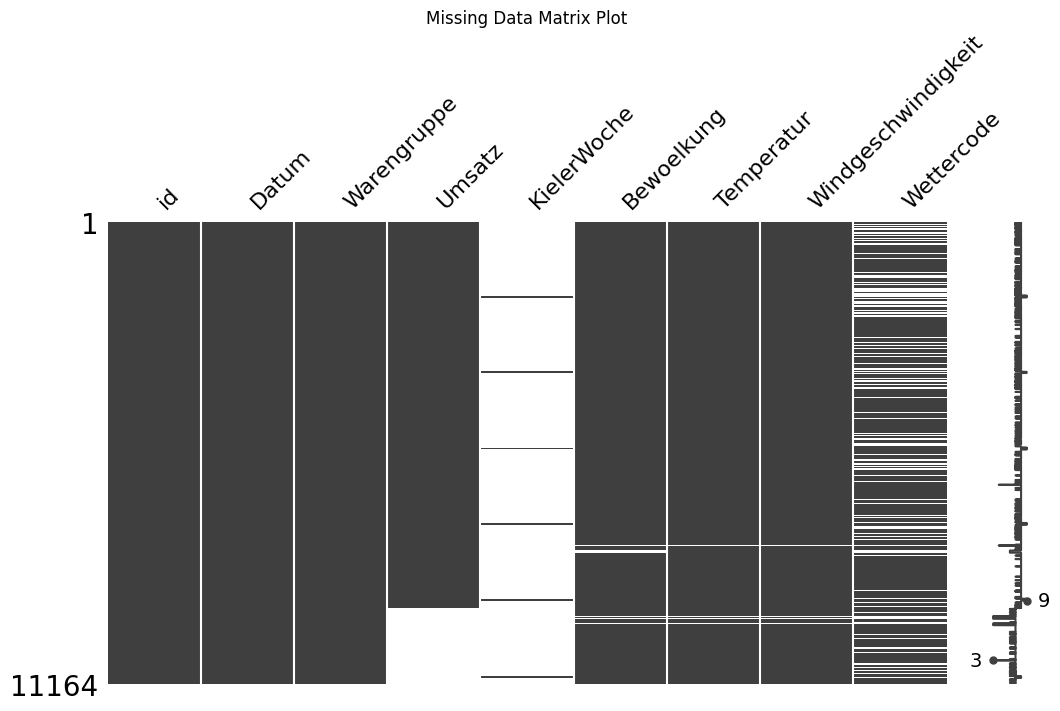

In [5]:
# Matrix plot of missing data
msno.matrix(merged_df, figsize=(12, 6))
plt.title('Missing Data Matrix Plot')
plt.show()

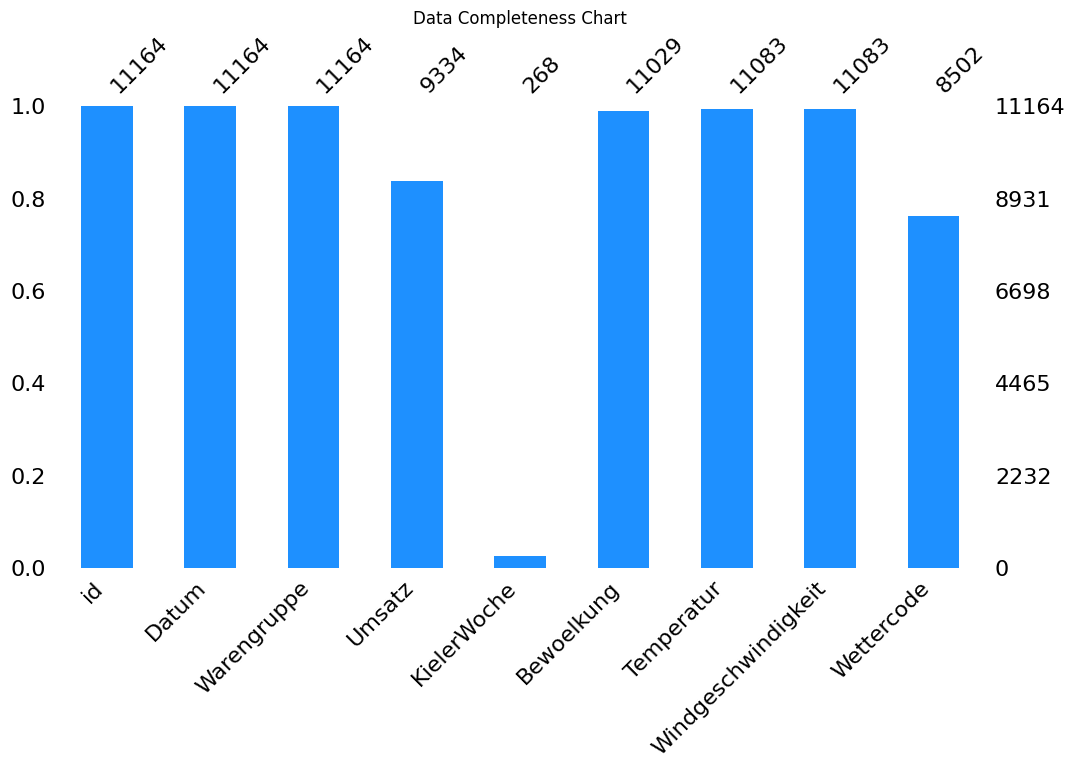

In [6]:
# Bar plot of complete data
msno.bar(merged_df, color="dodgerblue", figsize=(12, 6))
plt.title('Data Completeness Chart')
plt.show()

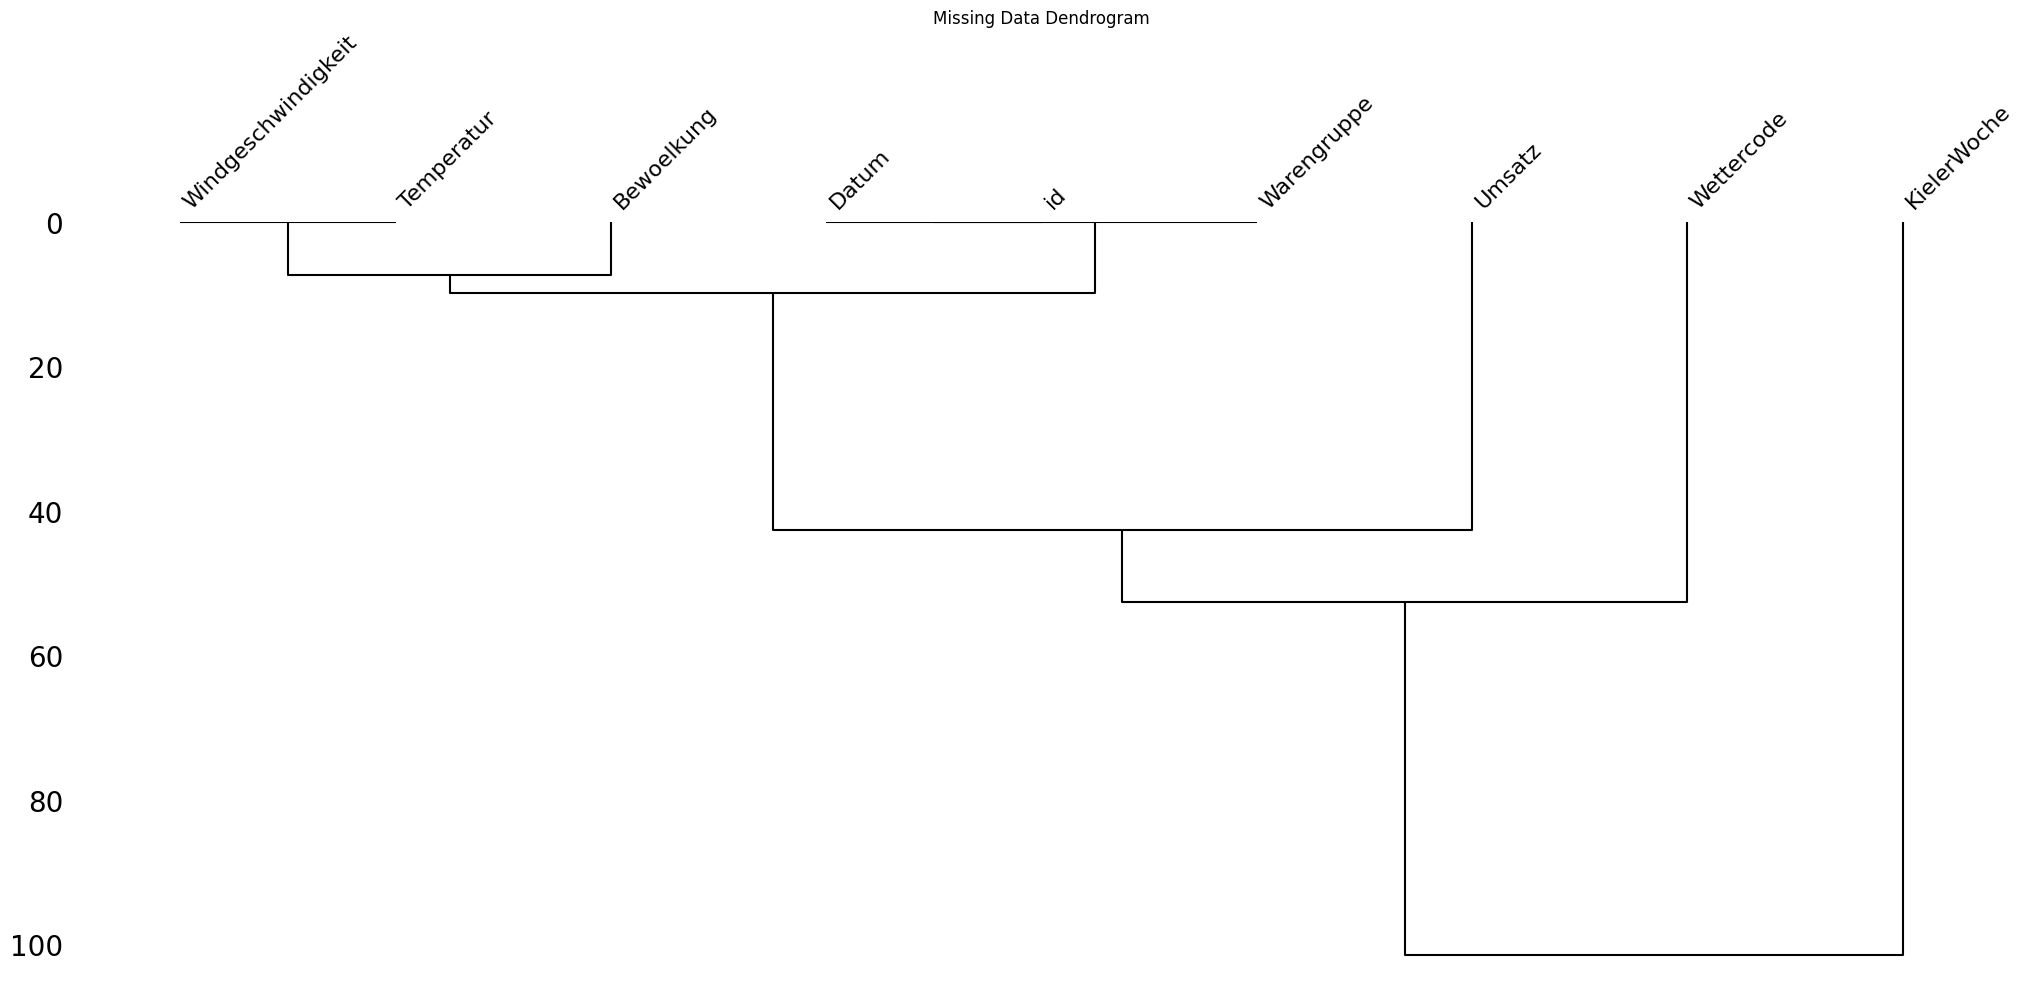

In [7]:
# Dendrogram to visualize the correlation of missingness between variables
msno.dendrogram(merged_df)
plt.title('Missing Data Dendrogram')
plt.show()

imputation of missing data

In [ ]:
mask = merged_df[['KielerWoche', 'Wettercode', 'Umsatz']].isna()

: 

In [ ]:
# Separate numeric and non-numeric columns
numeric_columns = merged_df.select_dtypes(include=[np.number])
non_numeric_columns = merged_df.select_dtypes(exclude=[np.number])

# Apply KNN imputation to numeric columns using scikit-learn's KNNImputer
from sklearn.impute import KNNImputer
imputer_knn = KNNImputer()
numeric_imputed = pd.DataFrame(imputer_knn.fit_transform(numeric_columns), columns=numeric_columns.columns)

# Combine imputed numeric data with non-numeric data
merged_df_knn = pd.concat([numeric_imputed, non_numeric_columns], axis=1)

In [ ]:
merged_df_knn = merged_df_knn.set_index(merged_df.index)

In [ ]:
print("Mask shape:", mask.shape)
print("Mask head:\n", mask.head())
print("Merged_df shape:", merged_df.shape)
print("Merged_df_knn shape:", merged_df_knn.shape)

Mask shape: (11164, 3)
Mask head:
    KielerWoche  Wettercode  Umsatz
0         True       False   False
1         True       False   False
2         True       False   False
3         True       False   False
4         True       False   False
Merged_df shape: (11164, 9)
Merged_df_knn shape: (11164, 9)


visualize imputed data

In [ ]:
def plot_scatter_with_imputation(merged_df, merged_df_knn, x, y, mask, title='Scatter Plot', xlabel='X-axis', ylabel='Y-axis'):
    plt.figure(figsize=(10, 6))
    
    # Dynamically calculate axis limits
    x_min = min(merged_df[x].min(), merged_df_knn[x].min()) - 10
    x_max = max(merged_df[x].max(), merged_df_knn[x].max()) + 10
    y_min = min(merged_df[y].min(), merged_df_knn[y].min()) - 10
    y_max = max(merged_df[y].max(), merged_df_knn[y].max()) + 10

    # Debugging: Print data
    print("Original Data (x):", merged_df[x].head())
    print("Imputed Data (x):", merged_df_knn[x].head())
    print("Mask:", mask.head())

    # Plot points
    sns.scatterplot(x=merged_df.loc[~mask[x], x], y=merged_df.loc[~mask[y], y], color='blue', label='Original')
    sns.scatterplot(x=merged_df_knn.loc[mask[x], x], y=merged_df_knn.loc[mask[y], y], color='red', label='Imputed')
    
    # Set consistent axis limits
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()